In [4]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/Udemy/bin/python


In [5]:
# versão do python
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

import os
# DRIVE_DIRECTORY = "curso_ml"
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

In [7]:
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix

# Regressão Logística

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

In [8]:
DRIVE_DIRECTORY_fonte ='../../2-3-Classificacao/Exercicio_Faltante_Classificacao'
with open(os.path.join(DRIVE_DIRECTORY_fonte, "cover_type_exer3.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

Instancie e ajuste um classificador do tipo `LogisticRegression`. Para garantir reprodutibilidade, informe `random_state=0` ao construtor.

In [12]:
# Cria o classificador de Regressão Logística
# random_state=0 garante que o resultado seja o mesmo toda vez que rodar
#lr_classifier = LogisticRegression(random_state=0)

# Treina o modelo: ele encontra os pesos ideais para cada característica (X)
# para prever a categoria correta da árvore (y)
#lr_classifier.fit(X_train, y_train)

# --- RESUMO DOS PARÂMETROS ---
# C=1.0: Equilíbrio entre precisão e simplicidade (regularização)
# penalty='l2': Evita que certas colunas dominem o modelo injustamente
# max_iter=100: O algoritmo tem 100 chances para convergir na melhor resposta
# solver='lbfgs': O algoritmo matemático padrão para otimização

In [9]:
lr_classifier = LogisticRegression(random_state=0)
lr_classifier.fit(X_train, y_train)

/home/fabiene/anaconda3/envs/Udemy/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
lr_classifier.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 0,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

C: 1.0: Controla a regularização (força do modelo). Valores menores de C tornam o modelo mais "simples" para evitar que ele decore os dados (overfitting).

penalty: 'l2': É o tipo de punição que o modelo recebe por ser muito complexo. O l2 é o padrão e ajuda a manter os pesos baixos.

max_iter: 100: É o número máximo de "tentativas" que o algoritmo tem para encontrar a melhor separação. Se o modelo der um erro de "ConvergenceWarning", devemos aumentar esse número (ex: 500 ou 1000).

solver: 'lbfgs': É o motor matemático que faz os cálculos de otimização. O lbfgs é eficiente para datasets pequenos e médios.

## Você deve receber um aviso de que o algoritmo não convergiu. Não se preocupe, isso significa que ou o algoritmo ou os parâmetros utilizados não são adequados para nosso dataset, mas isso faz parte da nossa pesquisa pelo melhor classificador.

### Exiba os coeficientes determinados pelo algoritmo.

In [11]:
lr_classifier.intercept_

array([ 0.39444079, -4.48811593, -1.4396563 , -1.41949224,  4.86885562,
       -2.00531638,  4.08928444])

como encontrar os melhores parâmetros para os algoritmos e melhores classificadores

### Exiba os coeficientes determinados pelo algoritmo.

In [13]:
lr_classifier.coef_

array([[-1.46217758e-01,  3.36102796e-04,  7.22845111e-02,
        -2.68201907e-01,  3.32154775e-01, -7.21473231e-01,
         1.02185225e-01,  2.22835747e-01, -1.17098886e-01,
        -1.03706102e-01,  1.19386381e+00, -2.51263295e-01,
         4.96009198e-01, -1.21807388e+00, -7.30220638e-02,
         1.07869550e-01, -8.99101763e-01, -1.87136725e-01,
        -5.38809199e-02, -3.81577594e-01, -1.40469868e-03,
        -6.91773475e-03, -6.00401154e-01, -2.11182718e-02,
         5.95753310e-01, -9.12934932e-01,  8.31664468e-01,
        -7.54425285e-02, -3.35080338e-01,  1.11504574e+00,
         7.80162545e-01,  3.18536583e-01, -3.62044414e-01,
        -4.03360310e-02, -5.56288652e-01, -2.14035688e-02,
        -2.14297285e-01, -7.15625216e-03, -2.58668412e-01,
        -1.12610387e-01, -1.86682567e-01,  6.73278334e-01,
         1.26505543e+00,  7.52185896e-01, -2.21607618e-01,
        -3.00112397e-01, -1.53134892e-01, -1.01407564e-02,
        -2.22837453e-03, -9.33364011e-04, -7.73314578e-0

### Observe que, como este dataset representa um problema com mais de uma classe, cada uma as 7 classes apresenta sua própria coleção de coeficientes para os 54 atributos:

In [14]:
lr_classifier.coef_.shape

(7, 53)

In [15]:
print(f'{lr_classifier.coef_.shape[0]} algoritmos e {lr_classifier.coef_.shape[1]} coeficientes')

7 algoritmos e 53 coeficientes


## Faça e exiba a predição no split de teste.

In [16]:
y_pred = lr_classifier.predict(X_test)

In [17]:
y_pred

array([4, 4, 1, ..., 4, 6, 5], shape=(2500,))

Calcule a acurácia.

In [18]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100:.2f} % de acurácia ou acerto')

tivemos 72.16 % de acurácia ou acerto


In [19]:
accuracy_score(y_test, y_pred)

0.7216

Exiba a matriz de confusão.

0.7216

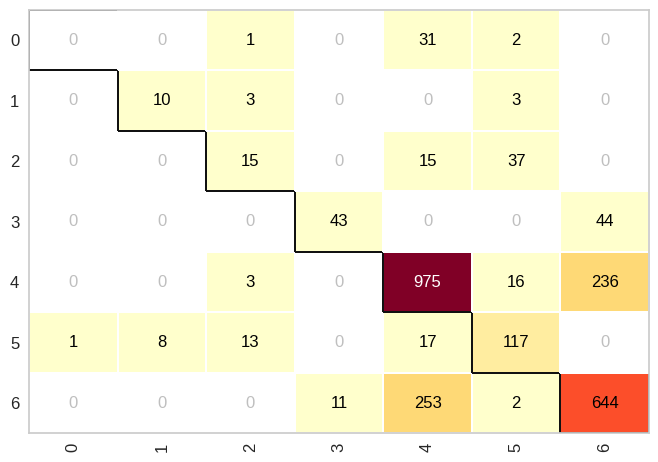

In [20]:
cm = ConfusionMatrix(lr_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

#### Eixo Vertical (True Class): É a realidade. O que a árvore realmente é no mundo real.

#### Eixo Horizontal (Predicted Class): É o palpite do modelo. O que o Regressão Logistica achou que era.

Exiba o reporte de classificação.

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.56      0.62      0.59        16
           2       0.43      0.22      0.29        67
           3       0.80      0.49      0.61        87
           4       0.76      0.79      0.77      1230
           5       0.66      0.75      0.70       156
           6       0.70      0.71      0.70       910

    accuracy                           0.72      2500
   macro avg       0.56      0.51      0.52      2500
weighted avg       0.71      0.72      0.71      2500



In [22]:
# melhor classe 3 pelo precision  
#e muito por na classe 0, com o recall e o precision 0

1. Precision (Precisão)
Pergunta: "De todas as vezes que o modelo disse que era Aspen, quantas eram realmente Aspen?"

Foco: Evitar alarmes falsos.

Se a precisão é 0.80, significa que quando o modelo aponta para uma árvore e diz "É Aspen", ele acerta 80% das vezes.

2. Recall (Revocação / Sensibilidade)
Pergunta: "De todas as árvores Aspen que existem de verdade no mato, quantas o modelo conseguiu encontrar?"

Foco: Não deixar passar nada.

Se o recall é 0.60, significa que o modelo só achou 60% das Aspens totais; as outras 40% ele confundiu com outro tipo.

3. F1-Score
O que é: Uma média (harmônica) entre a Precisão e o Recall.

Foco: Equilíbrio.

É a melhor métrica para olhar se você quer um resumo rápido, pois se a Precisão for ótima mas o Recall for péssimo (ou vice-versa), o F1-Score cai.

4. Support (Suporte)
O que é: A quantidade real de exemplos daquela classe no seu conjunto de testes.

Foco: Contexto.

Se o suporte de uma árvore é 10 e de outra é 5000, você sabe que o resultado da primeira não é tão confiável estatisticamente quanto o da segunda.

In [24]:
# o ideal é o Precision e o Recall elevados, bem próximo de 1.

In [25]:
from sklearn.preprocessing import LabelEncoder

# # 1. Recriamos o objeto
# label_encoder = LabelEncoder()

# # 2. "Ensinamos" a ele os nomes novamente usando a coluna original do DataFrame
# # Isso restaura a memória do encoder (o mapeamento de nomes para números)
# label_encoder.fit(base['Cover_Type'])

# # 3. Agora o comando vai funcionar!
# y_pred_strings = label_encoder.inverse_transform(y_pred)
# y_test_strings = label_encoder.inverse_transform(y_test)

# print("Nomes traduzidos com sucesso!")
# print(label_encoder.classes_)

#---------------------------------------

# # 1. Primeiro, geramos as previsões (que virão como números: 0, 1, 2...)
# y_pred = naive_classifier.predict(X_test)

# # 2. Agora, traduzimos os números de volta para os nomes das árvores
# y_pred_strings = label_encoder.inverse_transform(y_pred)

# # 3. Fazemos o mesmo para o y_test para podermos comparar "Nome vs Nome"
# y_test_strings = label_encoder.inverse_transform(y_test)

# # 4. Criamos uma tabela para você ver os 10 primeiros resultados reais
# import pandas as pd
# df_resultados = pd.DataFrame({
#     'Classe Real': y_test_strings,
#     'Previsão do Modelo': y_pred_strings
# })

# print("--- Primeiros 10 resultados traduzidos ---")
# print(df_resultados.head(10))
#----------------------------------

# # 1. Converte o array de números (y_pred) para os nomes originais (strings)
# y_pred_nomes = label_encoder.inverse_transform(y_pred)

# # 2. Se quiser ver os nomes reais do conjunto de teste para comparar
# y_test_nomes = label_encoder.inverse_transform(y_test)

# # 3. Vamos ver os 10 primeiros resultados lado a lado
# import pandas as pd
# comparacao = pd.DataFrame({
#     'Real': y_test_nomes,
#     'Previsão': y_pred_nomes
# })

# print(comparacao.head(10))

# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb


In [26]:
# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb
# y = base.iloc[:, -1].values
# base.columns[-1] # a coluna de interesse, o target, ou seja a classe é esta
# 'Cover_Type'

# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)
# # Mostra a lista de nomes na ordem (0, 1, 2...)
# print(label_encoder.classes_)
# {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 6: 'Spruce/Fir'}



In [27]:
import pandas as pd

# O seu dicionário de mapeamento
mapa_nomes = {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 
              3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 
              6: 'Spruce/Fir'}

# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame({
    'Real': y_test,
    'Previsão': y_pred
})

# Traduzindo as colunas usando o dicionário
df_comparacao['Real_Nome'] = df_comparacao['Real'].map(mapa_nomes)
df_comparacao['Previsao_Nome'] = df_comparacao['Previsão'].map(mapa_nomes)

display(df_comparacao[['Real_Nome', 'Previsao_Nome']].head(10))

,Real_Nome,Previsao_Nome
0,Lodgepole Pine,Lodgepole Pine
1,Lodgepole Pine,Lodgepole Pine
2,Cottonwood/Willow,Cottonwood/Willow
3,Lodgepole Pine,Lodgepole Pine
4,Lodgepole Pine,Spruce/Fir
5,Spruce/Fir,Spruce/Fir
6,Lodgepole Pine,Lodgepole Pine
7,Spruce/Fir,Spruce/Fir
8,Lodgepole Pine,Lodgepole Pine
9,Lodgepole Pine,Lodgepole Pine
